# Exercise 18 - ObsPy - Signal Processing

## 1. Data Processing Exercise

**Exercise 1.1:**

- Read all Tohoku example earthquake data into a stream object (`lecture_18/waveform_*`)
- Print the stream summary

In [1]:
from obspy import read

st = read("lecture_18/waveform_*")

print(st)

5 Trace(s) in Stream:
II.PFO.00.BHZ | 2011-03-11T05:46:23.019500Z - 2011-03-11T06:36:22.969500Z | 20.0 Hz, 60000 samples
II.PFO.10.BHZ | 2011-03-11T05:46:23.019500Z - 2011-03-11T06:36:22.994500Z | 40.0 Hz, 120000 samples
SY.PFO.S3.MXE | 2011-03-11T05:47:31.587750Z - 2011-03-11T06:36:22.974250Z | 6.2 Hz, 18152 samples
SY.PFO.S3.MXN | 2011-03-11T05:47:31.587750Z - 2011-03-11T06:36:22.974250Z | 6.2 Hz, 18152 samples
SY.PFO.S3.MXZ | 2011-03-11T05:47:31.587750Z - 2011-03-11T06:36:22.974250Z | 6.2 Hz, 18152 samples


**Exercise 1.2:**

Use **`st.select()`** to only keep traces of network `SY` in the stream. Show the preview plot.

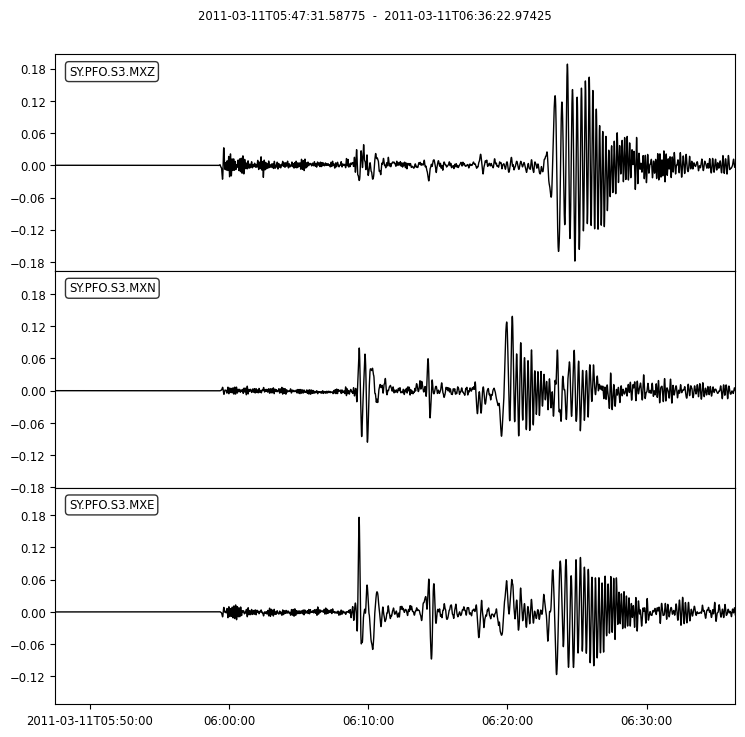

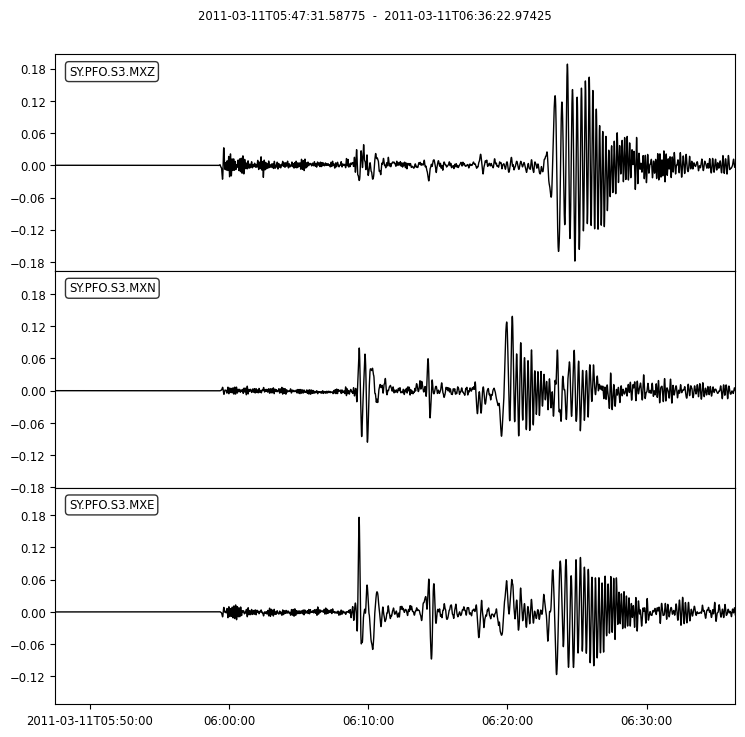

In [2]:
st = st.select(network="SY")

st.plot()

**Exercise 1.3:**

- trim the data to a 10 minute time window around the first arrival (just roughly looking at the preview plot)
- display the preview plot and spectrograms for the stream (with logarithmic frequency scale, use `wlen=50` for the spectrogram plot)

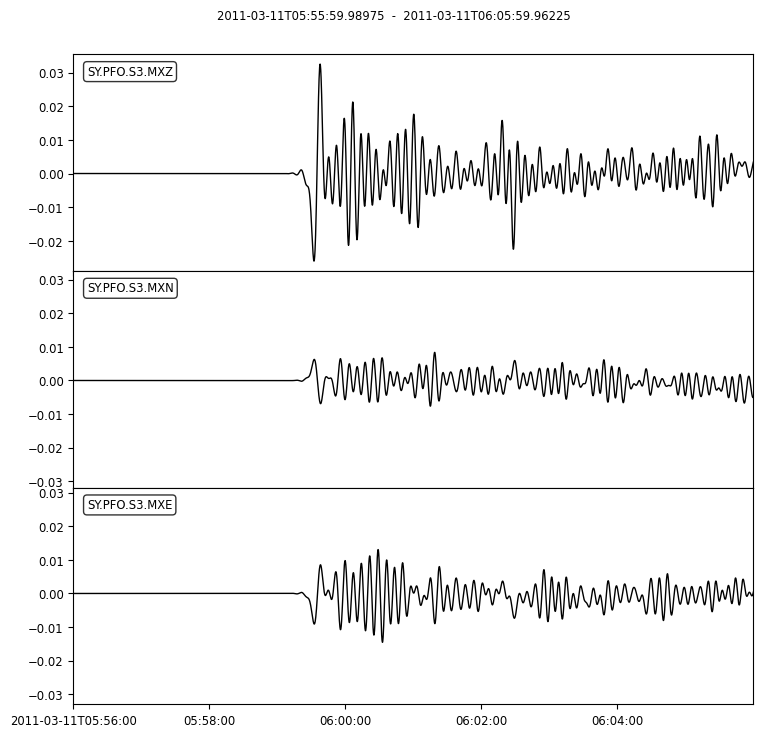

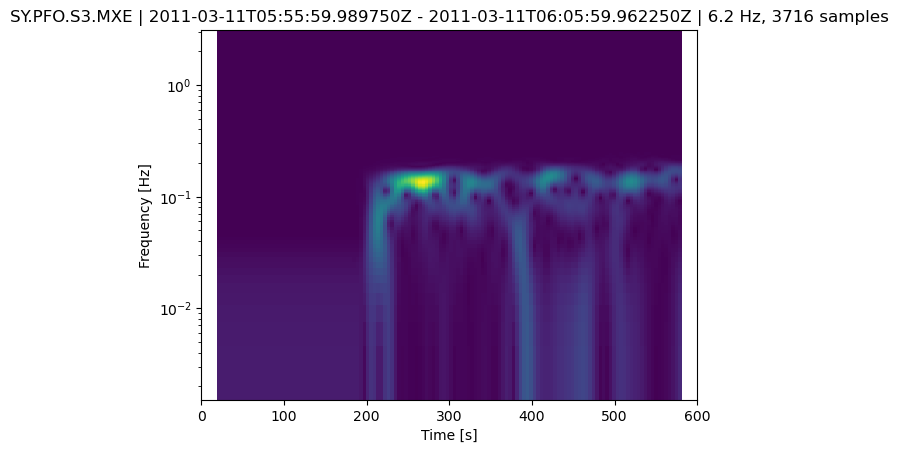

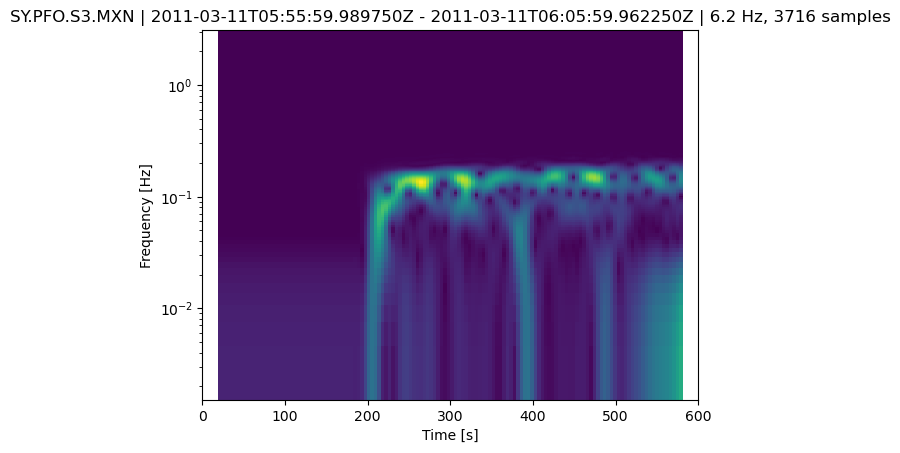

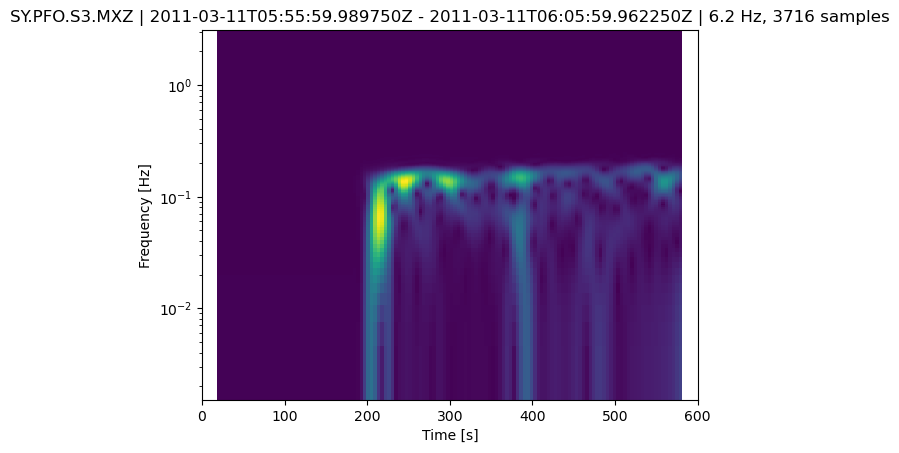

In [3]:
from obspy import UTCDateTime

t_arrival = UTCDateTime("2011-03-11T05:58:00")

st.trim(t_arrival - 120, t_arrival + 480)

st.plot()

for tr in st:
    tr.spectrogram(log=True, wlen=50)

- remove the linear trend from the data, apply a tapering and a lowpass at 0.1 Hertz
- show the preview plot again

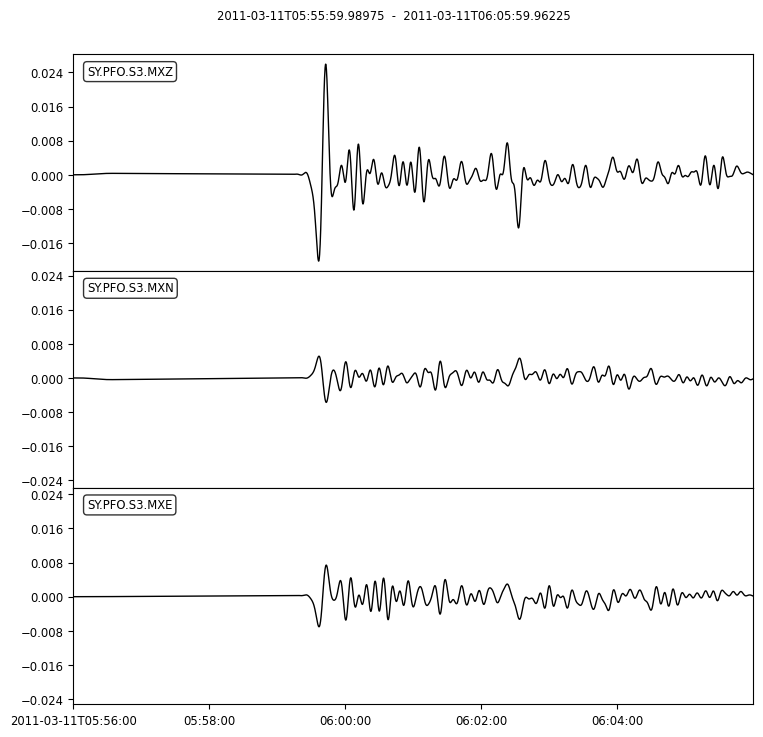

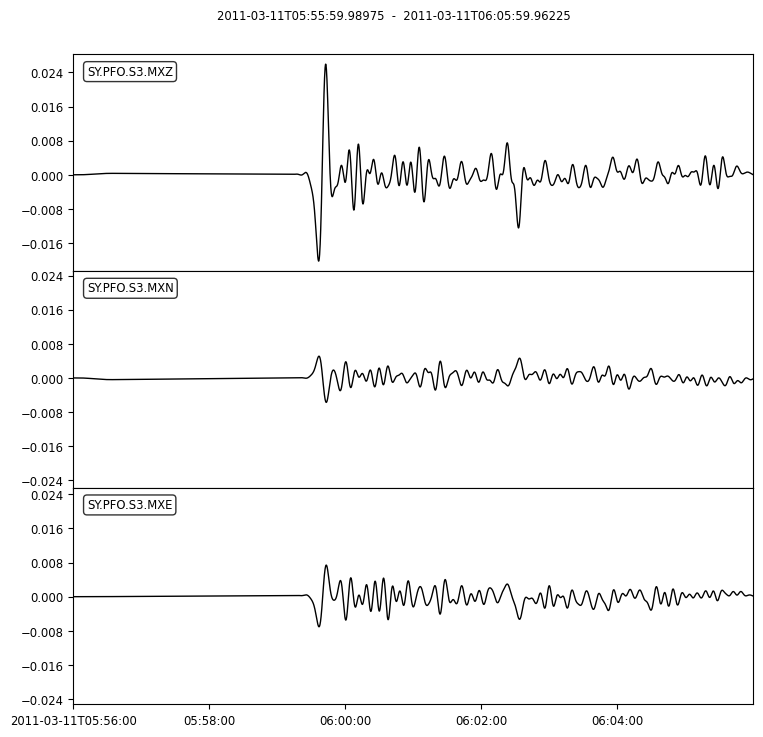

In [4]:

st.detrend("linear")


st.taper(max_percentage=0.05, type="hann")


st.filter("lowpass", freq=0.1)

st.plot()

## 2. Build a Stream from Scratch Exercise

**Exercise 2.1:**

 - Make an **`numpy.ndarray`** with zeros and (e.g. use **`numpy.zeros()`**) and put an ideal pulse somewhere in it
 - initialize a **`Trace`** object with your data array
 - Fill in some station information (e.g. network, station, ..)
 - Print trace summary and plot the trace

XX.PULSE..BHZ | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:16:39.000000Z | 1.0 Hz, 1000 samples


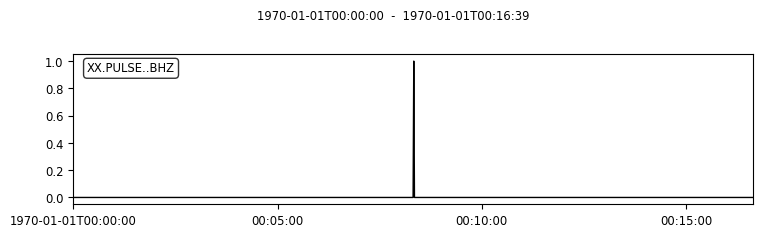

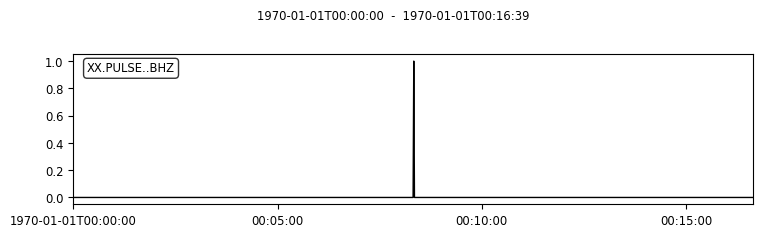

In [5]:
import numpy as np
from obspy import Trace

data = np.zeros(1000)

data[500] = 1.0

tr = Trace(data=data)

tr.stats.network = "XX"
tr.stats.station = "PULSE"
tr.stats.channel = "BHZ"

print(tr)
tr.plot()

 **Exercise 2.2:**
 
 - Change the sampling rate to 20 Hz
 - Change the starttime of the trace to the start time of this session
 - Print the trace summary and plot the trace again

XX.PULSE..BHZ | 2026-07-16T11:17:44.435304Z - 2026-07-16T11:18:34.385304Z | 20.0 Hz, 1000 samples


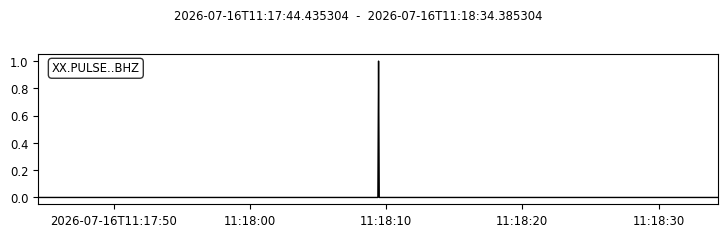

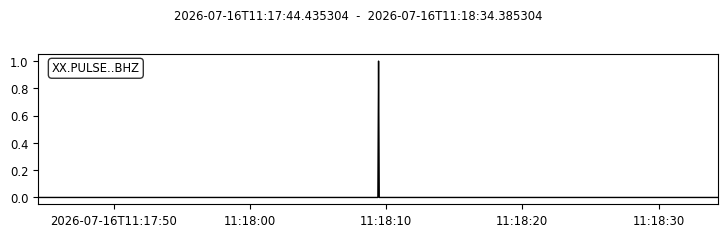

In [6]:
from obspy import UTCDateTime

tr.stats.sampling_rate = 20.0

tr.stats.starttime = UTCDateTime()

print(tr)
tr.plot()

**Exercise 2.3:**

- Use **`tr.filter(...)`** and apply a lowpass filter with a corner frequency of 1 Hertz.
- Display the preview plot.

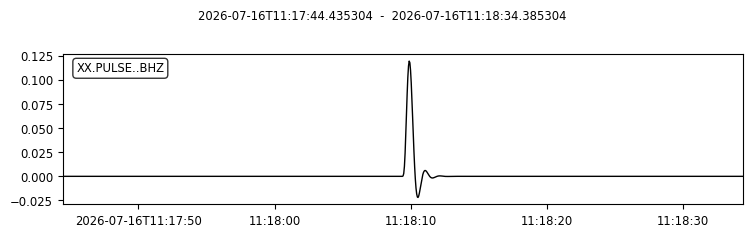

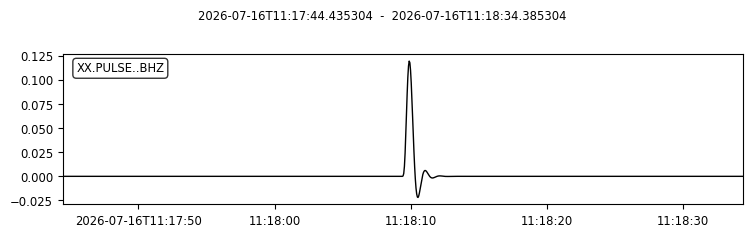

In [7]:
tr.filter("lowpass", freq=1.0)


tr.plot()

**Exercise 2.4:**

- Use **`tr.trim(...)`** to remove some of the zeros at start and at the end
- show the preview plot again

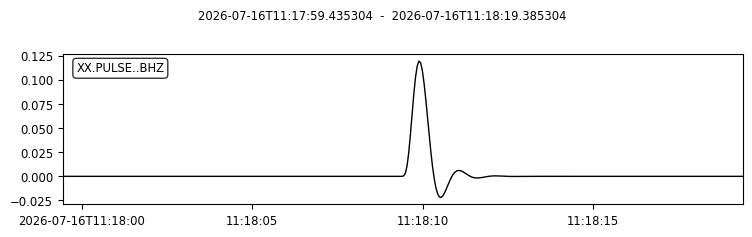

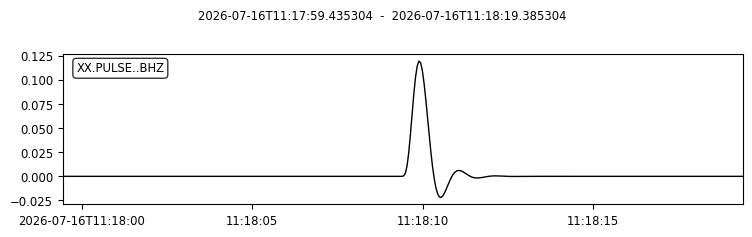

In [8]:
trim_start = tr.stats.starttime + 15
trim_end = tr.stats.endtime - 15


tr.trim(trim_start, trim_end)

tr.plot()

**Exercise 2.5:**

- Scale up the amplitudes of the trace by a factor of 500
- Add standard normal gaussian noise to the trace (use [**`np.random.randn()`**](http://docs.scipy.org/doc/numpy/reference/generated/numpy.random.randn.html))
- Display the preview plot again

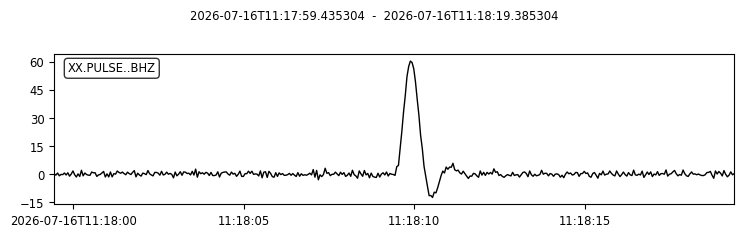

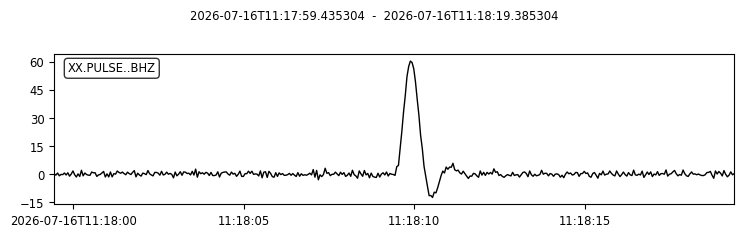

In [9]:
import numpy as np

tr.data = tr.data * 500

tr.data = tr.data + np.random.randn(len(tr.data))

tr.plot()